In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Load data
df = pd.read_csv('../data/raw/reviews.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (4482, 2)


,content,label
0,Gopaynya di perbaiki lagi utk masalah perbaika...,0
1,"Menu kurang, ajukan komplain, yg jawab AI, ada...",0
2,di bagian gofood banyak banget yang jelek nya ...,0
3,"Apk gk jelas, posisi drivernya suka diem terus...",0
4,"gojek ini mengerikan, sama seperti menipu penu...",0


In [3]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
content    0
label      0
dtype: int64


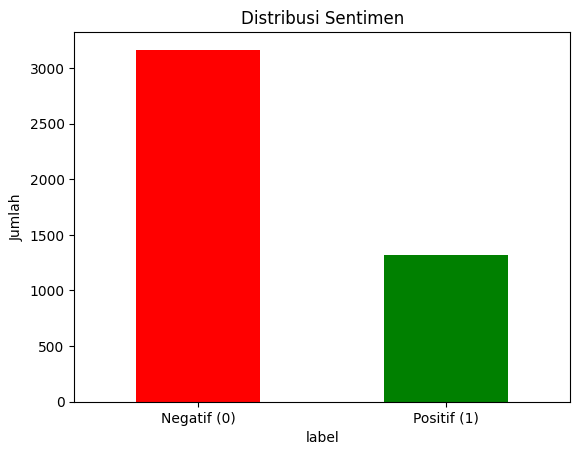

label
0    3163
1    1319
Name: count, dtype: int64


In [4]:
df['label'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Distribusi Sentimen')
plt.xticks([0, 1], ['Negatif (0)', 'Positif (1)'], rotation=0)
plt.ylabel('Jumlah')
plt.show()

print(df['label'].value_counts())

Statistik panjang teks:
count    4482.000000
mean      225.164659
std       132.082645
min        20.000000
25%       113.000000
50%       208.000000
75%       310.000000
max       757.000000
Name: text_length, dtype: float64


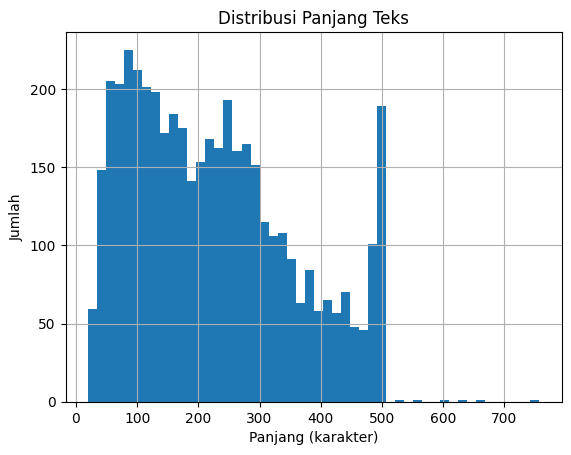

In [5]:
df['text_length'] = df['content'].apply(len)

print("Statistik panjang teks:")
print(df['text_length'].describe())

# Histogram
df['text_length'].hist(bins=50)
plt.title('Distribusi Panjang Teks')
plt.xlabel('Panjang (karakter)')
plt.ylabel('Jumlah')
plt.show()

In [6]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Fauzi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
# Setup stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Setup stopwords Indonesia
stopwords_id = set(stopwords.words('indonesian'))

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Hapus selain huruf dan spasi
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    tokens = text.split()
    # Hapus stopwords
    tokens = [word for word in tokens if word not in stopwords_id]
    # Stemming
    tokens = [stemmer.stem(word) for word in tokens]
    # Gabung lagi
    return ' '.join(tokens)

# Test fungsi
sample = df['content'].iloc[0]
print(f"Sebelum: {sample}")
print(f"Sesudah: {clean_text(sample)}")

Sebelum: Gopaynya di perbaiki lagi utk masalah perbaikan yg misal no akun ya hilang,, Kalo bisa dipermudah, Jangan mempersulit pengguna nya yg ingin mengaktifkan lagi ato mengganti nomernya,, terimakasih,, Mohon berhatihati bagi yg menyimpan uangnya disaldo gopay,, utk perbaikan secara lgsung lewat customernya juga tidak bisa,, pas ditelpon harus tetep lewat form diapk gopay,, udah gitu pertanyaan nya sangat mempersulit pengguna nya.. Sehingga nomer yg lama yg hilang tidak bisa diganti,, sekian trims
Sesudah: gopaynya baik utk baik yg no akun ya hilang kalo mudah sulit guna nya yg aktif ato ganti nomernya terimakasih mohon berhatihati yg simpan uang saldo gopay utk baik lgsung customernya pas telpon tetep form diapk gopay udah gitu nya sulit guna nya nomer yg yg hilang ganti sekian trims


In [8]:
print("Membersihkan teks...")

# Menggunakan .apply() untuk menjalankan fungsi clean_text ke setiap baris
df['cleaned'] = df['content'].apply(clean_text)

print("✅ Selesai!")
df[['content', 'cleaned', 'label']].head()

Membersihkan teks...
✅ Selesai!


,content,cleaned,label
0,Gopaynya di perbaiki lagi utk masalah perbaika...,gopaynya baik utk baik yg no akun ya hilang ka...,0
1,"Menu kurang, ajukan komplain, yg jawab AI, ada...",menu aju komplain yg ai aja alhasil ga proses ...,0
2,di bagian gofood banyak banget yang jelek nya ...,gofood banget jelek nya susah dapet driver tim...,0
3,"Apk gk jelas, posisi drivernya suka diem terus...",apk gk posisi drivernya suka diem tibatiba jal...,0
4,"gojek ini mengerikan, sama seperti menipu penu...",gojek keri tipu tumpang klu aplikasi sesuai al...,0


In [9]:
from sklearn.model_selection import train_test_split

X = df['cleaned']
y = df['label']

# Split 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Split temp jadi 50% val, 50% test (jadi 15% val, 15% test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train: {len(X_train)}")
print(f"Val  : {len(X_val)}")
print(f"Test : {len(X_test)}")

Train: 3137
Val  : 672
Test : 673


In [10]:
import os

# Bikin folder kalau belum ada
os.makedirs('../data/processed', exist_ok=True)

# Simpan
train_df = pd.DataFrame({'text': X_train, 'label': y_train})
val_df   = pd.DataFrame({'text': X_val,   'label': y_val})
test_df  = pd.DataFrame({'text': X_test,  'label': y_test})

train_df.to_csv('../data/processed/train.csv', index=False)
val_df.to_csv('../data/processed/val.csv', index=False)
test_df.to_csv('../data/processed/test.csv', index=False)

print("✅ Data train, val, test tersimpan di data/processed/")

✅ Data train, val, test tersimpan di data/processed/
